In [20]:
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

DATA_DIR = Path("../data/processed")

print("Libraries loaded with success.")

Libraries loaded with success.


In [21]:
df_cic = pl.read_parquet(DATA_DIR / "cicids2017_full.parquet")
df_unsw = pl.read_parquet(DATA_DIR / "unswnb15_full.parquet")

print(f"CIC-IDS2017: {df_cic.height:,} rows x {df_cic.width} columns")
print(f"UNSW-NB15: {df_unsw.height:,} rows x {df_unsw.width} columns")

CIC-IDS2017: 2,433,993 rows x 79 columns
UNSW-NB15: 257,673 rows x 45 columns


--- Class Distribution CIC-IDS2017
shape: (3, 3)
┌──────────┬─────────┬────────────┐
│ Label    ┆ count   ┆ percentage │
│ ---      ┆ ---     ┆ ---        │
│ str      ┆ u32     ┆ f64        │
╞══════════╪═════════╪════════════╡
│ BENIGN   ┆ 2273097 ┆ 93.39      │
│ PortScan ┆ 158930  ┆ 6.53       │
│ Bot      ┆ 1966    ┆ 0.08       │
└──────────┴─────────┴────────────┘


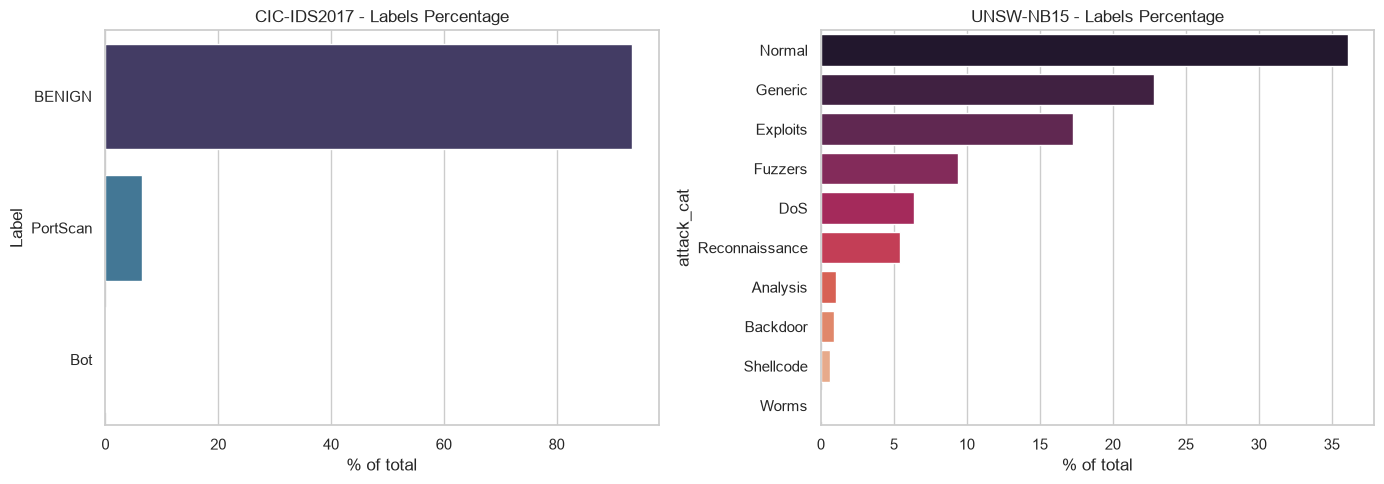

In [22]:
cic_labels = (
    df_cic.group_by("Label")
    .agg(pl.len().alias("count"))
    .with_columns((pl.col("count") / df_cic.height * 100).round(2).alias("percentage"))
    .sort("count", descending=True)
)

print("--- Class Distribution CIC-IDS2017")
print(cic_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=cic_labels.to_pandas(),
    x="percentage",
    y="Label",
    hue="Label",
    legend=False,
    ax=axes[0],
    palette="mako",
)
axes[0].set_title("CIC-IDS2017 - Labels Percentage")
axes[0].set_xlabel("% of total")


unsw_label_col = ("attack_cat" if "attack_cat" in df_unsw.columns else "label")
if unsw_label_col in df_unsw.columns:
    unsw_labels = (
        df_unsw.group_by(unsw_label_col)
        .agg(pl.len().alias("count"))
        .with_columns((pl.col("count") / df_unsw.height * 100).round(2).alias("percentage"))
        .sort("count", descending=True)
    )

    sns.barplot(
        data=unsw_labels.to_pandas(),
        x="percentage",
        y=unsw_label_col,
        hue=unsw_label_col,
        legend=False,
        ax=axes[1],
        palette="rocket",
    )
    axes[1].set_title("UNSW-NB15 - Labels Percentage")
    axes[1].set_xlabel("% of total")

plt.tight_layout()
plt.show()

In [23]:
null_summary = (
    df_cic.null_count()
    .transpose(include_header=True, header_name="colonna", column_names=["null_count"])
    .filter(pl.col("null_count") > 0)
    .with_columns((pl.col("null_count") / df_cic.height * 100)
                  .round(3)
                  .alias("null_percent")
                  )
)

print("Columns with NULL value in CIC-IDS2017")
print(null_summary)

Columns with NULL value in CIC-IDS2017
shape: (5, 3)
┌────────────────┬────────────┬──────────────┐
│ colonna        ┆ null_count ┆ null_percent │
│ ---            ┆ ---        ┆ ---          │
│ str            ┆ u32        ┆ f64          │
╞════════════════╪════════════╪══════════════╡
│ Flow Bytes/s   ┆ 810        ┆ 0.033        │
│ Flow Packets/s ┆ 730        ┆ 0.03         │
│ Active Mean    ┆ 4355       ┆ 0.179        │
│ Idle Mean      ┆ 38362      ┆ 1.576        │
│ Idle Std       ┆ 5445       ┆ 0.224        │
└────────────────┴────────────┴──────────────┘


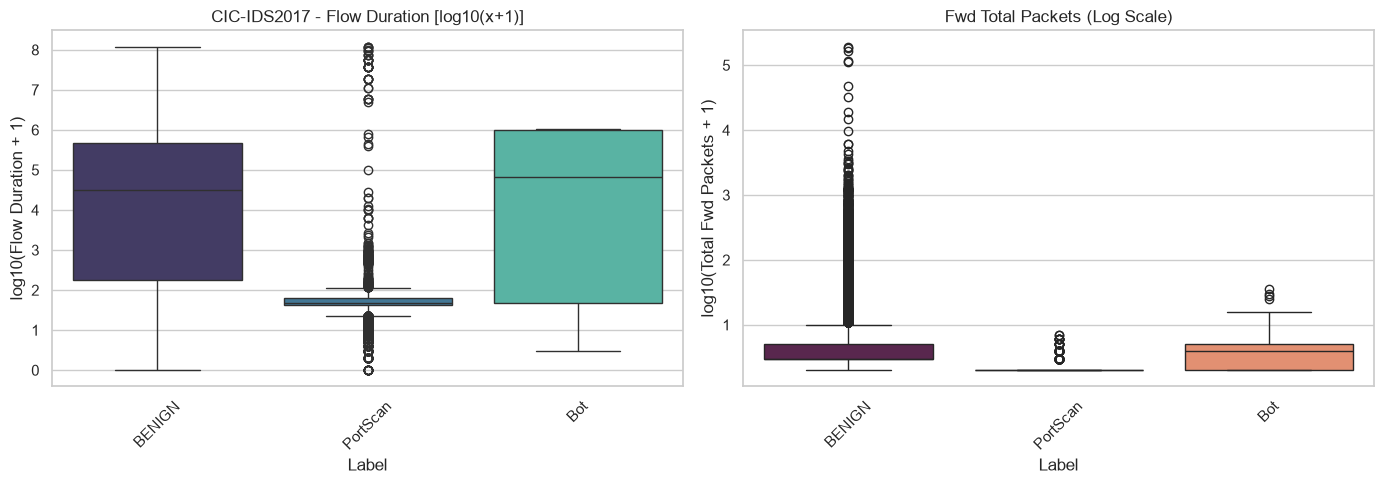

In [25]:
df_samples = (
    df_cic.filter(pl.col("Flow Duration") >= 0)
    .select(["Label", "Flow Duration", "Total Fwd Packets"])
    .sample(fraction=0.1, seed=42)
    .with_columns(
        (pl.col("Flow Duration") + 1).log10().alias("log_flow_duration"),
        (pl.col("Total Fwd Packets") + 1).log10().alias("log_fwd_packets"),
    )
    .to_pandas()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_samples, 
            x="Label", 
            y="log_flow_duration", 
            hue="Label",
            legend=False,
            ax=axes[0], 
            palette="mako"
            )
axes[0].set_title("CIC-IDS2017 - Flow Duration [log10(x+1)]")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("log10(Flow Duration + 1)")
axes[0].tick_params(axis="x", rotation=45)

sns.boxplot(data=df_samples, 
            x="Label", 
            y="log_fwd_packets", 
            hue="Label",
            legend=False,
            ax=axes[1], 
            palette="rocket",
            )
axes[1].set_title("Fwd Total Packets (Log Scale)")
axes[1].set_xlabel("Label")
axes[1].set_ylabel("log10(Total Fwd Packets + 1)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()